# Aspect-ratio sensitivity

Produces Figure 9.

In [1]:
import sys
sys.path.insert(0, "..")   # make src importable from the repository root

from src.utils import load_results

results = load_results("aspect_ratio_sensitivity")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from src.figstyle import (CATEGORICAL, DASHES, PALETTE, PT, figure,
                          panel_label, save_figure, threshold_line,
                          use_manuscript_style)

use_manuscript_style()
ar_results = results["aspect_ratios"]
N_TRIALS = results['params']['n_trials']


Wrote figures/fig9_aspect_ratio_sensitivity.pdf


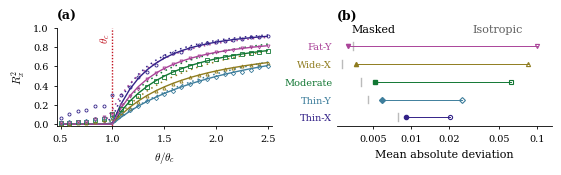

   regime   masked    noise  isotropic  ratio
   Thin-X   0.0092   0.0080     0.0205    2.2
   Thin-Y   0.0060   0.0046     0.0252    4.2
 Moderate   0.0052   0.0040     0.0621   12.0
   Wide-X   0.0037   0.0029     0.0843   23.0
    Fat-Y   0.0031   0.0035     0.0988   31.4
largest threshold gap: Fat-Y
largest ceiling gap: Wide-X


In [3]:
HEIGHT_PT = 118.0
SUP = 1.1   # supercritical signals enter the MAE

STYLE = {'Thin-X':   (CATEGORICAL[3], 'o'),
         'Fat-Y':    (CATEGORICAL[1], 'v'),
         'Moderate': (CATEGORICAL[5], 's'),
         'Wide-X':   (CATEGORICAL[2], '^'),
         'Thin-Y':   (CATEGORICAL[4], 'D')}

rows = []
for r in ar_results['configs']:
    tn = np.asarray(r['theta_values']) / r['theta_crit']
    m = np.asarray(r['Rx2_mean'])
    th = np.asarray(r['theory'])
    iso = np.asarray(r['theory_iso'])
    s = tn > SUP
    se = float((np.asarray(r['Rx2_std']) / np.sqrt(N_TRIALS))[s].mean())
    rows.append(dict(name=r['name'], tn=tn, m=m, th=th, iso=iso,
                     noise=se * np.sqrt(2 / np.pi),
                     mae_masked=float(np.abs(m - th)[s].mean()),
                     mae_iso=float(np.abs(m - iso)[s].mean()),
                     edge_gap=abs(r['theta_c_iso'] / r['theta_crit'] - 1),
                     ceiling_gap=abs(th[-1] - iso[-1])))

fig, axes = figure(HEIGHT_PT, 2)

ax = axes[0]
for r in rows:
    color, marker = STYLE[r['name']]
    ax.plot(r['tn'], r['iso'], color=color, lw=1.1, ls=DASHES['isotropic'],
            zorder=2)
    ax.plot(r['tn'], r['th'], color=color, lw=1.0, ls=DASHES['theory'], zorder=3)
    ax.plot(r['tn'], r['m'], marker, ms=2.2, mfc='none', mec=color, mew=0.6,
            lw=0, zorder=4)
threshold_line(ax, 1.0, r'$\theta_c$', y=0.90)
ax.set_xlabel(r'$\theta/\theta_c$')
ax.set_ylabel(r'$R_x^2$')
theta_min = min(float(r['tn'].min()) for r in rows)
theta_max = max(float(r['tn'].max()) for r in rows)
theta_margin = 0.0175 * (theta_max - theta_min)
ax.set_xlim(theta_min - theta_margin, theta_max + theta_margin)
ax.set_ylim(-0.02, 1.0)
ax.set_xticks(np.linspace(theta_min, theta_max, 5))
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
panel_label(ax, '(a)')

ax = axes[1]
order = sorted(rows, key=lambda r: r['mae_iso'])
for i, r in enumerate(order):
    color, marker = STYLE[r['name']]
    ax.plot([r['mae_masked'], r['mae_iso']], [i, i], '-', color=color, lw=0.7,
            zorder=2)
    ax.plot([r['noise'], r['noise']], [i - 0.22, i + 0.22], '-',
            color=PALETTE['grid'], lw=1.0, zorder=1)
    ax.plot(r['mae_masked'], i, marker, ms=3.0, color=color, mec=color, zorder=4)
    ax.plot(r['mae_iso'], i, marker, ms=3.0, mfc='none', mec=color, mew=0.8,
            zorder=4)
ax.set_xscale('log')
ax.minorticks_off()
ax.set_yticks(range(len(order)))
ax.set_yticklabels([r['name'] for r in order])
for label, r in zip(ax.get_yticklabels(), order):
    label.set_color(STYLE[r['name']][0])
ax.set_ylim(-0.5, len(order) + 0.05)
ax.set_xlim(0.0026, 0.13)
ax.set_xticks([0.005, 0.01, 0.02, 0.05, 0.1])
ax.set_xticklabels(['0.005', '0.01', '0.02', '0.05', '0.1'])
ax.tick_params(axis='y', length=0)
ax.spines['left'].set_visible(False)
ax.set_xlabel('Mean absolute deviation')
for xs, name, color in (
        (np.exp(np.mean([np.log(r['mae_masked']) for r in order])), 'Masked',
         PALETTE['theory']),
        (np.exp(np.mean([np.log(r['mae_iso']) for r in order])), 'Isotropic',
         PALETTE['isotropic'])):
    ax.text(xs, len(order) - 0.35, name, fontsize=PT['annot'], ha='center',
            va='bottom', color=color)
panel_label(ax, '(b)')

save_figure(fig, 'fig9_aspect_ratio_sensitivity')
plt.show()

print(f"{'regime':>9} {'masked':>8} {'noise':>8} {'isotropic':>10} {'ratio':>6}")
for r in order:
    print(f"{r['name']:>9} {r['mae_masked']:8.4f} {r['noise']:8.4f} {r['mae_iso']:10.4f} "
          f"{r['mae_iso'] / r['mae_masked']:6.1f}")
print('largest threshold gap:', max(rows, key=lambda r: r['edge_gap'])['name'])
print('largest ceiling gap:', max(rows, key=lambda r: r['ceiling_gap'])['name'])
